# Member 2: Graphs, Residuals & Feature Importance

This notebook completes the Member 2 part of the CSM3601 AAPL stock price prediction project.

**Member 2 outputs included in this notebook:**

1. Actual vs Predicted graph  
2. Residual Plot  
3. RMSE Comparison graph  
4. Feature Importance graph  
5. Short explanation for each graph


## 1. Project Context

The locked selected model is **Ridge Regression**.

Final test performance of the locked model:

| Metric | Value |
|---|---:|
| MAE | 2.1196 |
| MSE | 8.2735 |
| RMSE | 2.8764 |
| R² Score | 0.9873 |
| Directional Accuracy | 49.00% |

Important note: the Persistence Baseline remained a strong benchmark. Therefore, the correct conclusion is that **Ridge Regression was the best-performing trained machine learning model**, not that it beat the baseline on every metric.


## 2. Import Libraries


In [1]:
from io import StringIO
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True


## 3. Load Data

This notebook is self-contained. It can load data from local CSV files if they are available. If not, it will use the embedded project data inside this notebook.

Expected local file names:
- `test_predictions.csv`
- `test_model_comparison.csv`
- `permutation_feature_importance.csv`


In [2]:
TEST_PREDICTIONS_CSV = 'Date,Current_Close,Actual_Target_Close,Persistence_Baseline,Linear Regression,Ridge Regression,Random Forest,XGBoost\n2024-01-02,183.56219482421875,182.187744140625,183.56219482421875,183.8242851139608,183.81487786046978,184.3373387145778,179.62534\n2024-01-03,182.187744140625,179.87396240234375,182.187744140625,183.08466669653762,183.05869335059234,183.95466176076252,181.8095\n2024-01-04,179.87396240234375,179.15208435058594,179.87396240234375,180.45663045404706,180.43381012279565,179.74378201599959,179.21786\n2024-01-05,179.15208435058594,183.48306274414065,179.15208435058594,179.38158803445117,179.39041105899338,178.48936249725668,176.63324\n2024-01-08,183.48306274414065,183.0677795410156,183.48306274414065,183.40444980682366,183.37138853120138,183.3085992675094,180.72844\n2024-01-09,183.0677795410156,184.10606384277344,183.0677795410156,183.1649207573779,183.13913799490894,183.84261737980094,181.27321\n2024-01-10,184.10606384277344,183.51275634765625,184.10606384277344,184.27830411773562,184.24645760043924,183.86829895666844,181.9538\n2024-01-11,183.51275634765625,183.83908081054688,183.51275634765625,183.1800842291148,183.20665219242863,184.08041863847092,181.7069\n2024-01-12,183.83908081054688,181.57467651367188,183.83908081054688,184.23934675849,184.2340516344836,184.7635459427497,183.65695\n2024-01-16,181.57467651367188,180.63528442382807,181.57467651367188,181.74501154382187,181.70162129760496,181.5410104499595,180.10626\n2024-01-17,180.63528442382807,186.51870727539065,180.63528442382807,180.98965825564613,180.950963639382,179.8835753387229,181.88806\n2024-01-18,186.51870727539065,189.4159240722656,186.51870727539065,186.63582967247447,186.62491932536017,185.44540645583075,186.41287\n2024-01-19,189.4159240722656,191.7198486328125,189.4159240722656,189.42522656632195,189.40272934847374,188.18999580127164,189.02448\n2024-01-22,191.7198486328125,192.9954071044922,191.7198486328125,192.0084093730913,191.9899048131075,191.40492459666552,191.05965\n2024-01-23,192.9954071044922,192.3230438232422,192.9954071044922,192.95601191681055,192.96329825338103,192.22288337706723,191.8586\n2024-01-24,192.3230438232422,191.9967041015625,192.3230438232422,192.8193587097702,192.82236834511076,191.93546518519048,190.7439\n2024-01-25,191.9967041015625,190.26626586914065,191.9967041015625,191.98158593204982,192.00256811700962,191.5585160491041,191.64919\n2024-01-26,190.26626586914065,189.5840301513672,190.26626586914065,190.42531134910251,190.44925182489854,189.8328247254274,189.79182\n2024-01-29,189.5840301513672,185.93533325195312,189.5840301513672,189.30355574906753,189.3089604444656,187.58836147843476,189.11794\n2024-01-30,185.93533325195312,182.33604431152344,185.93533325195312,186.02916443449982,186.06754380459319,186.5021595918902,186.42085\n2024-01-31,182.33604431152344,184.7684936523437,182.33604431152344,182.67519755536495,182.69891347998072,184.6664676576631,182.34982\n2024-02-01,184.7684936523437,183.76983642578125,184.7684936523437,185.2124763348147,185.16291719720095,184.06805667877123,183.50569\n2024-02-02,183.76983642578125,185.579330444336,183.76983642578125,184.38516608907406,184.26823879317038,182.21995805523196,182.1097\n2024-02-05,185.579330444336,187.18121337890625,185.579330444336,185.2986366427319,185.3336453891498,185.84898680966432,186.63315\n2024-02-06,187.18121337890625,187.2899780273437,187.18121337890625,187.5519388311071,187.50886865458614,186.25098721166452,186.91197\n2024-02-07,187.2899780273437,186.2122039794922,187.2899780273437,187.3148972247467,187.34126470724897,187.90005438019625,187.14395\n2024-02-08,186.2122039794922,186.9745178222656,186.2122039794922,186.10475968402926,186.12174972796728,187.04878682451297,186.65825\n2024-02-09,186.9745178222656,185.2914123535156,186.9745178222656,187.45496982021524,187.4434812787331,187.8829963911514,188.10309\n2024-02-12,185.2914123535156,183.2023468017578,185.2914123535156,185.5321828576134,185.53904841937089,186.77672276495713,184.87384\n2024-02-13,183.2023468017578,182.3212127685547,183.2023468017578,183.1642353725427,183.16657744800824,184.27776900449268,182.8496\n2024-02-14,182.3212127685547,182.03407287597656,182.3212127685547,182.0900919042221,182.11464379134816,184.34098322523042,181.78015\n2024-02-15,182.03407287597656,180.4994964599609,182.03407287597656,181.91401230548604,181.9106153055392,183.50103553017186,182.28687\n2024-02-16,180.4994964599609,179.75694274902344,180.4994964599609,180.88644053536774,180.89424281844174,181.64134262290224,182.10956\n2024-02-20,179.75694274902344,180.50938415527344,179.75694274902344,179.8055815735555,179.80512980084927,179.27900768081858,181.98053\n2024-02-21,180.50938415527344,182.5390472412109,180.50938415527344,180.66757046775604,180.6620442252814,180.2632675748557,181.97449\n2024-02-22,182.5390472412109,180.7074279785156,182.5390472412109,182.59266447542888,182.58706998493636,183.64546473524373,181.86414\n2024-02-23,180.7074279785156,179.3609161376953,180.7074279785156,180.59885521419682,180.64205270368132,182.34500658619126,181.78433\n2024-02-26,179.3609161376953,180.8163146972656,179.3609161376953,179.6510901111837,179.65811447103775,179.06735564482557,178.21648\n2024-02-27,180.8163146972656,179.6183319091797,180.8163146972656,180.94952897643213,180.93110291300627,180.2940448026711,181.8125\n2024-02-28,179.6183319091797,178.95498657226562,179.6183319091797,179.5871373414949,179.60347713785208,179.3433458701867,181.63455\n2024-02-29,178.95498657226562,177.87582397460938,178.95498657226562,179.23408996056716,179.25304350972834,178.29809497959138,178.11238\n2024-03-01,177.87582397460938,173.36109924316406,177.87582397460938,177.89571685979615,177.89560566703855,176.82679804361447,177.23073\n2024-03-04,173.36109924316406,168.4305419921875,173.36109924316406,173.6569128850206,173.64709543534389,172.82812016418515,173.23589\n2024-03-05,168.4305419921875,167.4404754638672,168.4305419921875,169.2441662577886,169.21274061415426,167.4247886514127,168.72835\n2024-03-06,167.4404754638672,167.32167053222656,167.4404754638672,167.78380106511256,167.8110572537688,167.64111641828748,168.43987\n2024-03-07,167.32167053222656,169.03448486328125,167.32167053222656,168.00927578857062,167.99867569765215,167.20356627866266,168.58418\n2024-03-08,169.03448486328125,171.03443908691406,169.03448486328125,169.86838417240938,169.83851418867982,169.63163255603445,169.61012\n2024-03-11,171.03443908691406,171.50965881347656,171.03443908691406,171.28758575063367,171.30294378024007,171.139871844906,171.69608\n2024-03-12,171.50965881347656,169.43052673339844,171.50965881347656,171.2426256706972,171.25492842029587,171.85036100533802,172.03879\n2024-03-13,169.43052673339844,171.2819366455078,169.43052673339844,169.5989591631563,169.61700704854428,169.9837798067579,170.04646\n2024-03-14,171.2819366455078,170.90570068359375,171.2819366455078,171.60657577182604,171.61180228774103,171.46939217906274,171.70813\n2024-03-15,170.90570068359375,171.99478149414062,170.90570068359375,171.0335234264961,171.00801479146946,171.80897275709623,171.85559\n2024-03-18,171.99478149414062,174.33135986328125,171.99478149414062,172.32488549947038,172.3706713533232,172.67593741315451,172.81776\n2024-03-19,174.33135986328125,176.89564514160156,174.33135986328125,174.1594274544714,174.15000247108293,174.28538140031412,173.81087\n2024-03-20,176.89564514160156,169.6681365966797,176.89564514160156,176.906671029645,176.86979455212753,176.7423840642499,176.67845\n2024-03-21,169.6681365966797,170.569091796875,169.6681365966797,169.18683908420115,169.2797862344456,169.57600212524343,168.3801\n2024-03-22,170.569091796875,169.1533203125,170.569091796875,170.70321786585683,170.70227973745392,171.88585633504422,171.60286\n2024-03-25,169.1533203125,168.0246124267578,169.1533203125,169.66382927770331,169.63975111511252,169.73738415311183,169.38536\n2024-03-26,168.0246124267578,171.58885192871094,168.0246124267578,168.73951625537956,168.72197011837926,167.91564756757634,168.46523\n2024-03-27,171.58885192871094,169.7770233154297,171.58885192871094,171.56916288396778,171.54038703545936,171.81093883472815,171.9871\n2024-03-28,169.7770233154297,168.34144592285156,169.7770233154297,170.10354811684996,170.09199797346457,169.79523241623787,170.75133\n2024-04-01,168.34144592285156,167.16323852539062,168.34144592285156,168.41889918340252,168.43203906511584,168.32635505967056,168.21426\n2024-04-02,167.16323852539062,167.9652099609375,167.16323852539062,167.54333308336,167.53050653006835,166.04370429743858,168.46523\n2024-04-03,167.9652099609375,167.14346313476562,167.9652099609375,168.64506917343203,168.61881384306997,168.10778871473477,168.61015\n2024-04-04,167.14346313476562,167.8959197998047,167.14346313476562,167.53645339626854,167.55205077693498,167.11146375388623,168.324\n2024-04-05,167.8959197998047,166.77713012695312,167.8959197998047,168.2375896669185,168.23473354457678,168.10494874870054,168.51357\n2024-04-08,166.77713012695312,167.98501586914062,166.77713012695312,167.1416370066406,167.13532768261805,165.44423584578507,166.01353\n2024-04-09,167.98501586914062,166.11378479003906,167.98501586914062,168.33933401057612,168.3193773288196,167.51404641138208,168.20102\n2024-04-10,166.11378479003906,173.30166625976562,166.11378479003906,166.2158838495323,166.22036595770447,164.70163343223476,165.96144\n2024-04-11,173.30166625976562,174.79669189453125,173.30166625976562,173.3033936003315,173.23933823071957,172.53413450302213,172.63048\n2024-04-12,174.79669189453125,170.9750213623047,174.79669189453125,175.19762703686985,175.1628650322928,174.17950987640157,173.42448\n2024-04-15,170.9750213623047,167.6979217529297,170.9750213623047,171.16689485233366,171.2001034379721,170.1611006675544,170.42026\n2024-04-16,167.6979217529297,166.3315887451172,167.6979217529297,167.85376818919147,167.8843934952494,167.58005234158435,167.12033\n2024-04-17,166.3315887451172,165.38111877441406,166.3315887451172,167.18767487918677,167.19283268398925,166.73889963600567,165.7975\n2024-04-18,165.38111877441406,163.3614044189453,165.38111877441406,165.62291715116038,165.62708259950574,166.24009504043744,166.34874\n2024-04-19,163.3614044189453,164.19305419921875,163.3614044189453,163.34358962845184,163.35578215481559,163.88805137858287,162.84682\n2024-04-22,164.19305419921875,165.24249267578125,164.19305419921875,164.7069933696446,164.69862274665206,165.62458297359726,165.17023\n2024-04-23,165.24249267578125,167.34149169921875,165.24249267578125,165.53347828795688,165.5056464731452,165.01301025040127,166.17111\n2024-04-24,167.34149169921875,168.2028350830078,167.34149169921875,167.51097755803085,167.4769634764954,167.29701370359524,168.28171\n2024-04-25,168.2028350830078,167.61871337890625,168.2028350830078,168.05957885382713,168.06215461332425,167.9480830321794,168.07611\n2024-04-26,167.61871337890625,171.7769775390625,167.61871337890625,168.2016404037223,168.19765358527962,167.83194475398452,168.05438\n2024-04-29,171.7769775390625,168.63845825195312,171.7769775390625,172.28575283783158,172.3002970908674,171.97057521639542,171.37537\n2024-04-30,168.63845825195312,167.61871337890625,168.63845825195312,168.7741182694109,168.81597678500356,167.99792158783214,168.22192\n2024-05-01,167.61871337890625,171.3116455078125,167.61871337890625,168.5878232103759,168.57108962159407,168.4894209469845,168.05005\n2024-05-02,171.3116455078125,181.5588836669922,171.3116455078125,171.0355109165936,171.0579778506886,171.07885505433654,171.2143\n2024-05-03,181.5588836669922,179.90545654296875,181.5588836669922,180.3711375916788,180.53902903500574,183.30763089672743,180.44173\n2024-05-06,179.90545654296875,180.58856201171875,179.90545654296875,179.68796872158617,179.70655911145178,179.07342414257448,181.39626\n2024-05-07,180.58856201171875,180.9252166748047,180.58856201171875,180.47900226783054,180.5144415873648,180.57402685402093,181.01454\n2024-05-08,180.9252166748047,182.737060546875,180.9252166748047,181.04708568862105,181.0484850428818,181.64082206398535,180.79727\n2024-05-09,182.737060546875,181.4779663085937,182.737060546875,182.99848136393766,182.96039800141435,183.41777278746457,181.58476\n2024-05-10,181.4779663085937,184.6802215576172,181.4779663085937,180.96394008730843,181.0017705737826,183.55563304538148,181.39996\n2024-05-13,184.6802215576172,185.82032775878903,184.6802215576172,184.79585047236083,184.79735997212424,184.6554336947154,184.25653\n2024-05-14,185.82032775878903,188.0906982421875,185.82032775878903,185.83121163482184,185.83851290177316,185.81247707429515,186.39421\n2024-05-15,188.0906982421875,188.2096405029297,188.0906982421875,188.26241182342397,188.23865520817006,187.29119545021825,187.03368\n2024-05-16,188.2096405029297,188.2393798828125,188.2096405029297,188.43121710955808,188.43740771772093,188.59553189739324,187.74583\n2024-05-17,188.2393798828125,189.3993530273437,188.2393798828125,188.81074967666126,188.78765809743453,188.24758903978912,187.72096\n2024-05-20,189.3993530273437,190.69808959960932,189.3993530273437,189.76006148645627,189.72238710902965,188.17492502781107,188.89598\n2024-05-21,190.69808959960932,189.26052856445312,190.69808959960932,191.06699736851797,191.03616574489936,190.61264072003002,190.22147\n2024-05-22,189.26052856445312,185.27505493164065,189.26052856445312,189.30032969635636,189.31610375026787,188.62652137573102,188.44281\n2024-05-23,185.27505493164065,188.34841918945312,185.27505493164065,185.09677269039372,185.16336506941173,186.62971328591098,184.4791\n2024-05-24,188.34841918945312,188.35836791992188,188.34841918945312,188.65351704669172,188.64142100813402,187.6641491976326,187.64745\n2024-05-28,188.35836791992188,188.65577697753903,188.35836791992188,188.4461302141608,188.47760613134238,187.9571868608118,187.50194\n2024-05-29,188.65577697753903,189.647201538086,188.65577697753903,189.30240994113097,189.27647205090966,187.45471092440638,187.90399\n2024-05-30,189.647201538086,190.59896850585932,189.647201538086,190.11004715930875,190.0925325134891,187.9009663825436,188.72333\n2024-05-31,190.59896850585932,192.36366271972656,190.59896850585932,190.59410151326773,190.58506037292165,189.4915493804134,189.35526\n2024-06-03,192.36366271972656,192.6809234619141,192.36366271972656,192.66862610362438,192.65072740907976,191.76817079954492,192.0162\n2024-06-04,192.6809234619141,194.18783569335932,192.6809234619141,192.61539351454547,192.62291429481098,192.48511233734624,191.93172\n2024-06-05,194.18783569335932,192.809799194336,194.18783569335932,194.5041779268716,194.49480545767,193.54795855089307,192.24745\n2024-06-06,192.809799194336,195.19911193847656,192.809799194336,193.12988018204447,193.13805132899137,192.29863642836932,191.27902\n2024-06-07,195.19911193847656,191.46145629882807,195.19911193847656,195.35217935978903,195.31651492408906,193.21246350370868,193.16444\n2024-06-10,191.46145629882807,205.3710021972656,191.46145629882807,191.04977264940584,191.12567143128206,191.6039523892522,191.47272\n2024-06-11,205.3710021972656,211.2401580810547,205.3710021972656,204.8753639346197,204.74260959974902,193.14819059292344,192.89903\n2024-06-12,211.2401580810547,212.40011596679688,211.2401580810547,211.92065078695305,211.8718348587368,193.37773800125277,193.97008\n2024-06-13,212.40011596679688,210.6651306152344,212.40011596679688,211.69103853165376,211.74619562922447,193.12187198718397,193.0532\n2024-06-14,210.6651306152344,214.8092193603516,210.6651306152344,210.46374471453072,210.49421783992761,193.09022824234836,192.20534\n2024-06-17,214.8092193603516,212.4496612548828,214.8092193603516,215.59115179127787,215.5430527450289,193.31077718742839,192.73967\n2024-06-18,212.4496612548828,207.87925720214844,212.4496612548828,211.7915107735024,211.87230126021421,193.11615007071217,192.49634\n2024-06-20,207.87925720214844,205.7080535888672,207.87925720214844,207.38914267280308,207.47230478571907,193.1207149665901,191.81049\n2024-06-21,205.7080535888672,206.3524627685547,205.7080535888672,206.2010281436077,206.27013456978068,193.05166386706117,191.34023\n2024-06-24,206.3524627685547,207.2745056152344,206.3524627685547,207.75510181858198,207.74301618792822,193.27290693896327,193.04158\n2024-06-25,207.2745056152344,211.41860961914065,207.2745056152344,207.88610889393877,207.8820365404727,193.22677883939426,193.27383\n2024-06-26,211.41860961914065,212.2613220214844,211.41860961914065,211.52639252263066,211.52038823203765,193.295542295067,193.21478\n2024-06-27,212.2613220214844,208.8111724853516,212.2613220214844,212.0379605261553,212.06630156604024,193.0248263086833,193.09016\n2024-06-28,208.8111724853516,214.88853454589844,208.8111724853516,208.34799746937614,208.46553519807279,193.08355007773284,191.0598\n2024-07-01,214.88853454589844,218.37831115722656,214.88853454589844,215.20142337897562,215.1447995474494,193.26440760318556,192.95662\n2024-07-02,218.37831115722656,219.64732360839844,218.37831115722656,218.2112041990248,218.15354332697245,193.27656223661876,193.21965\n2024-07-03,219.64732360839844,224.39617919921875,219.64732360839844,219.43430463131563,219.41169921730886,192.98361545702772,192.50099\n2024-07-05,224.39617919921875,225.8634796142578,224.39617919921875,224.41454322285279,224.34896149016748,193.23904635188796,192.81554\n2024-07-08,225.8634796142578,226.7160797119141,225.8634796142578,224.80471308041513,224.82672396616493,193.30555819723708,193.16412\n2024-07-09,226.7160797119141,230.9791717529297,226.7160797119141,226.50844880170456,226.5003005136266,193.15309964257878,193.5891\n2024-07-10,230.9791717529297,225.6156311035156,230.9791717529297,231.11474466118875,231.05844504533053,193.2637737242135,192.94717\n2024-07-11,225.6156311035156,228.5601043701172,225.6156311035156,225.03872219919543,225.11475051905887,193.08118909352612,191.43265\n2024-07-12,228.5601043701172,232.386947631836,228.5601043701172,229.24480116737533,229.21681440847982,193.31133024386745,193.18777\n2024-07-15,232.386947631836,232.8033447265625,232.386947631836,231.8624280324932,231.9561441647058,193.15719495999997,192.06749\n2024-07-16,232.8033447265625,226.9143524169922,232.8033447265625,232.4670575836348,232.4851055667143,193.0189758269003,192.21338\n2024-07-17,226.9143524169922,222.25473022460932,226.9143524169922,226.87640933457698,226.85171504838706,193.06013964621357,192.11026\n2024-07-18,222.25473022460932,222.3836212158203,222.25473022460932,221.46544480143234,221.61270616975793,193.1273963946512,190.96051\n2024-07-19,222.3836212158203,222.03662109375,222.3836212158203,223.15576273279436,223.15235251834878,193.0251075485639,192.923\n2024-07-22,222.03662109375,223.0776214599609,222.03662109375,221.8186011140549,221.89734283044305,193.02999503552076,192.10838\n2024-07-23,223.0776214599609,216.66314697265625,223.0776214599609,223.1728315682256,223.1689119206677,193.0138400210905,192.10533\n2024-07-24,216.66314697265625,215.6221923828125,216.66314697265625,216.0778038945419,216.19125644678928,193.10109017468622,190.96492\n2024-07-25,215.6221923828125,216.08816528320312,215.6221923828125,215.51496260773501,215.55703223168706,193.00080287862806,191.83325\n2024-07-26,216.08816528320312,216.36575317382807,216.08816528320312,216.057087159635,216.07995087071907,192.8836555641865,191.3273\n2024-07-29,216.36575317382807,216.92095947265625,216.36575317382807,216.7010464110769,216.66859817529706,192.95963691723148,192.11427\n2024-07-30,216.92095947265625,220.17274475097656,216.92095947265625,216.34144264443535,216.37254925304183,192.95560345886082,192.11137\n2024-07-31,220.17274475097656,216.4846954345703,220.17274475097656,220.62347072772008,220.62620069748272,193.22269273596342,193.27098\n2024-08-01,216.4846954345703,217.9718170166016,216.4846954345703,215.3889751708195,215.5462602312216,193.11792911282708,190.7282\n2024-08-02,217.9718170166016,207.4727478027344,217.9718170166016,218.96730448839145,218.96788641029332,193.2326349422924,192.41689\n2024-08-05,207.4727478027344,205.45030212402344,207.4727478027344,208.2018453237513,207.94648062491123,193.20018248122116,192.33247\n2024-08-06,205.45030212402344,208.0180511474609,205.45030212402344,205.46560643666885,205.4350106488316,193.1741307830373,192.88695\n2024-08-07,208.0180511474609,211.47808837890625,208.0180511474609,209.07693377959515,209.02536363801312,193.31479211890644,193.28621\n2024-08-08,211.47808837890625,214.3829345703125,211.47808837890625,210.41661362264387,210.47162675089845,193.1888819453008,193.20012\n2024-08-09,214.3829345703125,215.91146850585932,214.3829345703125,214.36501392253325,214.30411876820648,193.09158347506687,192.33408\n2024-08-12,215.91146850585932,219.6236572265625,215.91146850585932,216.5753938945798,216.54772695686802,193.07978270978424,192.28082\n2024-08-13,219.6236572265625,220.0702972412109,219.6236572265625,220.02173931629198,219.9903574754838,193.12382732057418,192.37445\n2024-08-14,220.0702972412109,223.0479736328125,220.0702972412109,220.34459586385668,220.3180305914775,193.11615718806848,192.3875\n2024-08-15,223.0479736328125,224.3680725097656,223.0479736328125,222.6789265018491,222.7054234772487,193.0921642591395,192.36293\n2024-08-16,224.3680725097656,224.20925903320312,224.3680725097656,224.7331605142814,224.68656837443967,193.11404176656524,192.43668\n2024-08-19,224.20925903320312,224.8246612548828,224.20925903320312,223.68753966477112,223.69309339219154,193.0136264920215,192.21338\n2024-08-20,224.8246612548828,224.7154693603516,224.8246612548828,225.28878875135155,225.2611402959608,192.94265049912957,192.25754\n2024-08-21,224.7154693603516,222.859375,224.7154693603516,225.0389708789058,225.03213500196603,192.91138751990522,192.11137\n2024-08-22,222.859375,225.15220642089844,222.859375,222.65144536105197,222.72434747329794,192.89590817170895,190.8168\n2024-08-23,225.15220642089844,225.48963928222656,225.15220642089844,225.35319234795287,225.34126949233683,193.10447597789369,192.18369\n2024-08-26,225.48963928222656,226.33334350585932,225.48963928222656,224.9401000139303,224.94477771406764,192.9859881323199,192.21338\n2024-08-27,226.33334350585932,224.8047790527344,226.33334350585932,226.48236451104833,226.44002523605735,192.95328919327457,192.12032\n2024-08-28,224.8047790527344,228.0802459716797,224.8047790527344,225.12629199783373,225.14617264521894,192.82732147935198,191.13513\n2024-08-29,228.0802459716797,227.296127319336,228.0802459716797,228.65243882082672,228.6771582120861,193.21654557610563,192.68321\n2024-08-30,227.296127319336,221.11248779296875,227.296127319336,226.9796959561429,227.0079518803273,193.08546346728716,192.40941\n2024-09-03,221.11248779296875,219.206771850586,221.11248779296875,220.24380280511963,220.37261172588296,192.9835298518051,191.32462\n2024-09-04,219.206771850586,220.7253875732422,219.206771850586,218.63063738474472,218.65151173259028,192.8701503478594,191.25813\n2024-09-05,220.7253875732422,219.176986694336,220.7253875732422,222.0697589512418,222.0374661535605,193.06789501533873,192.26453\n2024-09-06,219.176986694336,219.26632690429688,219.176986694336,218.90639900610142,218.98353229064423,193.00828443045336,191.8432\n2024-09-09,219.26632690429688,218.4722595214844,219.26632690429688,218.1870712522765,218.21707746329287,193.25405182993077,192.65996\n2024-09-10,218.4722595214844,221.00331115722656,218.4722595214844,218.6479387941261,218.62047587738022,193.13093959335393,193.14406\n2024-09-11,221.00331115722656,221.11248779296875,221.00331115722656,220.19581855019135,220.21308416880333,193.16909496467687,192.37282\n2024-09-12,221.11248779296875,220.844482421875,221.11248779296875,220.6406403012378,220.64848128802112,193.00277170717808,192.3066\n2024-09-13,220.844482421875,214.71046447753903,220.844482421875,221.04070928107262,221.05711513366816,192.84750525892443,191.49548\n2024-09-16,214.71046447753903,215.1769561767578,214.71046447753903,214.7971298836382,214.75751883359146,193.17351022627196,192.13416\n2024-09-17,215.1769561767578,219.04795837402344,215.1769561767578,215.5836633286254,215.55344093127275,193.01834715448004,192.1115\n2024-09-18,219.04795837402344,227.16709899902344,219.04795837402344,219.78921828265237,219.73855455383057,193.2643821349428,192.94531\n2024-09-19,227.16709899902344,226.50205993652344,227.16709899902344,227.05207711866473,227.03513696805726,193.27387134016644,193.12454\n2024-09-20,226.50205993652344,224.78494262695312,226.50205993652344,227.14927850345288,227.24117660511985,193.0796862327608,191.68242\n2024-09-23,224.78494262695312,225.67825317382807,224.78494262695312,225.81747753071664,225.8316669859389,193.07973681902016,192.21909\n2024-09-24,225.67825317382807,224.68569946289065,225.67825317382807,225.56615657130942,225.60916723345343,192.89687826697582,191.25127\n2024-09-25,224.68569946289065,225.82711791992188,224.68569946289065,225.2344686292215,225.18014983388048,193.04296900899627,192.50099\n2024-09-26,225.82711791992188,226.09510803222656,225.82711791992188,225.5969034359082,225.60439587238386,193.04338404362582,192.61046\n2024-09-27,226.09510803222656,231.266342163086,226.09510803222656,226.49460383853847,226.50068460070787,192.81359521923352,191.52834\n2024-09-30,231.266342163086,224.52688598632807,231.266342163086,231.3930143437043,231.36163397311788,193.26417390155896,192.74905\n2024-10-01,224.52688598632807,225.09263610839844,224.52688598632807,223.61338425702985,223.67294304293802,193.07723041193793,191.54408\n2024-10-02,225.09263610839844,223.99090576171875,225.09263610839844,224.89088139349855,224.88778212677812,193.02456084862118,191.96016\n2024-10-03,223.99090576171875,225.1125030517578,223.99090576171875,224.25358422905617,224.22639231152448,192.9520974692069,192.08688\n2024-10-04,225.1125030517578,220.04054260253903,225.1125030517578,224.49446828936635,224.54366044434056,192.87177843958835,191.25731\n2024-10-07,220.04054260253903,224.09014892578125,220.04054260253903,220.13677442747957,220.1677582450517,192.9284750312298,190.82181\n2024-10-08,224.09014892578125,227.8321228027344,224.09014892578125,224.39220395854915,224.38093860517938,193.05213204190602,192.23888\n2024-10-09,227.8321228027344,227.3358154296875,227.8321228027344,227.9811109171863,227.91067520102303,193.066747800574,192.34012\n2024-10-10,227.3358154296875,225.8569183349609,227.3358154296875,227.64464114874164,227.6019152463076,192.96385028159997,192.22232\n2024-10-11,225.8569183349609,229.5790100097656,225.8569183349609,225.89159982272668,225.917838928297,192.7661056372075,191.04633\n2024-10-14,229.5790100097656,232.1100311279297,229.5790100097656,230.2239970854485,230.17620167300385,193.11988430201538,191.87578\n2024-10-15,232.1100311279297,230.05545043945312,232.1100311279297,232.58816627170938,232.60218803464636,193.32204393298235,192.99762\n2024-10-16,230.05545043945312,230.4226837158203,230.05545043945312,229.96886102630037,229.95111148522494,192.9399984775129,192.34184\n2024-10-17,230.4226837158203,233.25148010253903,230.4226837158203,230.1438362466011,230.1840991872645,192.87061563919588,191.3384\n2024-10-18,233.25148010253903,234.720458984375,233.25148010253903,233.1678073648635,233.2153442099367,192.9255324581114,190.95909\n2024-10-21,234.720458984375,234.1050720214844,234.720458984375,235.1768129563332,235.12572900896782,192.96998349037978,192.3836\n2024-10-22,234.1050720214844,229.0430145263672,234.1050720214844,234.0692176540261,234.01873651693643,193.06661213274077,192.36432\n2024-10-23,229.0430145263672,228.85446166992188,229.0430145263672,228.27092144115522,228.3464880096954,193.01346471983152,190.96584\n2024-10-24,228.85446166992188,229.68820190429688,228.85446166992188,229.22374760461497,229.1982380506248,192.92811771102475,191.96924\n2024-10-25,229.68820190429688,231.6633758544922,229.68820190429688,230.58593239252144,230.53307233989517,193.0332634995242,191.85442\n2024-10-28,231.6633758544922,231.931381225586,231.6633758544922,232.01948091034143,232.02069644881226,192.96792494233785,192.27263\n2024-10-29,231.931381225586,228.3879547119141,231.931381225586,232.151743742973,232.13108385028892,192.96546986284505,192.3066\n2024-10-30,228.3879547119141,224.2291259765625,228.3879547119141,228.66365690342963,228.6957554080218,192.940244991674,191.02472\n2024-10-31,224.2291259765625,221.25143432617188,224.2291259765625,224.3670262437783,224.42148192563644,193.0588033455085,190.92496\n2024-11-01,221.25143432617188,220.3581085205078,221.25143432617188,222.45689506813943,222.37212658561225,193.20689109508754,192.24261\n2024-11-04,220.3581085205078,221.78741455078125,220.3581085205078,220.8714184511304,220.8314105305298,193.06965455040898,192.40279\n2024-11-05,221.78741455078125,221.0628662109375,221.78741455078125,222.21809874719128,222.18242275227692,192.93398286415837,192.22673\n2024-11-06,221.0628662109375,225.7874298095703,221.0628662109375,221.76608998055656,221.75616676306822,193.2488416986967,192.82962\n2024-11-07,225.7874298095703,225.51914978027344,225.7874298095703,226.1687533332119,226.13364783963561,193.12583300483578,192.38522\n2024-11-08,225.51914978027344,222.8064727783203,225.51914978027344,226.04341899361754,226.03424194862168,192.99237564702372,192.36783\n2024-11-11,222.8064727783203,222.8064727783203,222.8064727783203,222.39470637365935,222.4069849658253,192.8946516668405,191.33333\n2024-11-12,222.8064727783203,223.69081115722656,222.8064727783203,223.2312529523852,223.2273320901482,192.97470794322365,192.21779\n2024-11-13,223.69081115722656,226.77114868164065,223.69081115722656,224.18369624146982,224.15712726761348,193.14148293261545,193.10336\n2024-11-14,226.77114868164065,223.5715789794922,226.77114868164065,227.12696573433857,227.07105758729318,193.1159824736472,192.75038\n2024-11-15,223.5715789794922,226.5724334716797,223.5715789794922,223.68686359944627,223.69358132799675,192.92884762313602,191.65678\n2024-11-18,226.5724334716797,226.8307647705078,226.5724334716797,227.35387651008938,227.30283946703196,193.1753537465491,192.4344\n2024-11-19,226.8307647705078,227.5461883544922,226.8307647705078,227.62487627504674,227.58194484641513,192.98815167265442,192.31554\n2024-11-20,227.5461883544922,227.0692443847656,227.5461883544922,227.37240847242805,227.36304741900705,192.9764913456622,192.19855\n2024-11-21,227.0692443847656,228.41065979003903,227.0692443847656,226.5507994391512,226.572757748068,192.9933650974994,192.36977\n2024-11-22,228.41065979003903,231.39163208007807,228.41065979003903,229.22470266235894,229.1733786223,193.00003579487083,192.27347\n2024-11-25,231.39163208007807,233.56771850585932,231.39163208007807,231.18053167478428,231.18488556052836,193.31999335083535,193.00685\n2024-11-26,233.56771850585932,233.4385681152344,233.56771850585932,234.09377828933202,234.0600313987594,193.04870326287158,192.41489\n2024-11-27,233.4385681152344,235.8233184814453,233.4385681152344,233.784896311075,233.76192674813547,192.91444105231147,192.3066\n2024-11-29,235.8233184814453,238.0689392089844,235.8233184814453,236.0259519699261,235.98158954368427,193.05438123493806,192.29332\n2024-12-02,238.0689392089844,241.10952758789065,238.0689392089844,238.66174179185214,238.61281695711926,193.47221190240964,192.91287\n2024-12-03,241.10952758789065,241.4672393798828,241.10952758789065,241.0304558733722,240.988975011018,193.4515828018889,192.66335\n2024-12-04,241.4672393798828,241.4970703125,241.4672393798828,241.37940928880795,241.3785353249968,193.3309665202156,192.55957\n2024-12-05,241.4970703125,241.2983245849609,241.4970703125,241.6144715525632,241.6317899627993,193.0687345851942,191.44875\n2024-12-06,241.2983245849609,245.18348693847656,241.2983245849609,241.90523296750706,241.88780339044501,193.27786056362547,192.3963\n2024-12-09,245.18348693847656,246.1970367431641,245.18348693847656,245.6033479115921,245.51126293838223,193.5524155729431,192.57222\n2024-12-10,246.1970367431641,244.92515563964844,246.1970367431641,246.03206136790834,246.01851639079416,193.3540705427656,192.54265\n2024-12-11,244.92515563964844,246.3858337402344,244.92515563964844,245.57176716817247,245.59025956445288,193.2656364823296,191.14737\n2024-12-12,246.3858337402344,246.5547332763672,246.3858337402344,246.62751169729597,246.60580259982834,193.3330742915898,192.2976\n2024-12-13,246.5547332763672,249.4462738037109,246.5547332763672,246.81458378444353,246.7984047676827,193.35158287724033,192.37747\n2024-12-16,249.4462738037109,251.87075805664065,249.4462738037109,249.7103080300745,249.65240580093246,193.67342216038176,193.01862\n2024-12-17,251.87075805664065,246.47525024414065,251.87075805664065,252.11992989656653,252.05124825178734,193.67982006459556,193.388\n2024-12-18,246.47525024414065,248.2041931152344,246.47525024414065,246.67313639189962,246.74462338013194,193.5979010328813,191.59706\n2024-12-19,248.2041931152344,252.8743896484375,248.2041931152344,249.0565817042268,249.0021126900345,193.71621212389488,193.0095\n2024-12-20,252.8743896484375,253.64942932128903,252.8743896484375,252.55526443674154,252.4772275912419,193.62957012623914,193.0399\n2024-12-23,253.64942932128903,256.5608215332031,253.64942932128903,253.8368746295152,253.8330374437785,193.2454048464394,192.54265\n2024-12-24,256.5608215332031,257.37554931640625,256.5608215332031,256.7127558962847,256.66454416241595,193.29402699766237,192.45541\n2024-12-26,257.37554931640625,253.9673767089844,257.37554931640625,257.97306562223787,257.93930289210357,193.25279010642296,192.43025\n2024-12-27,253.9673767089844,250.59890747070312,253.9673767089844,253.43700915274553,253.48694207187418,192.8446193224715,190.10872\n2024-12-30,250.59890747070312,248.8302154541016,250.59890747070312,251.13809995139093,251.09478936397062,192.95957598391803,191.86044\n'

TEST_MODEL_COMPARISON_CSV = 'Model,MAE,MSE,RMSE,R2,Directional_Accuracy,Locked_Selection\nPersistence Baseline,2.1046768127684565,8.182982039534922,2.8605912045475708,0.9874300426388138,0.00398406374501992,False\nRidge Regression,2.1196076199427236,8.2734903637416,2.8763675640887065,0.9872910119320845,0.4900398406374502,True\nLinear Regression,2.1212017325414014,8.292553507401827,2.8796794105250374,0.9872617288538836,0.5059760956175299,False\nRandom Forest,19.415341790782126,687.6151876633105,26.222417654810368,-0.05625229874305138,0.40239043824701193,False\nXGBoost,19.895061720889878,721.6217639676752,26.863018519289213,-0.10849012745641895,0.450199203187251,False\n'

PERMUTATION_FEATURE_IMPORTANCE_CSV = 'Feature,Importance_Mean,Importance_Std\nClose,24.13466908422337,0.6993986123576069\nLow,12.341769683497363,0.3929828967690303\nOpen,11.007398585953357,0.38550140547784706\nMA7,3.2352166675146496,0.17494559199796372\nHigh,3.008278288732298,0.1735049067846049\nClose_Lag5,0.8026353610544469,0.10311609391015636\nClose_Lag1,0.18360639821237149,0.05533531572982964\nLog_Return,0.1520223843189116,0.04270671983690236\nDaily_Return,0.10068788057302311,0.04034201898597493\nVolume_Change,0.008362800742926672,0.007702240321397899\nLog_Volume_Change,0.007956036051360667,0.007645348705781584\nPrice_Range,0.006314127181259869,0.0029428958559777757\nOpen_Close_Change,0.0002247787779137885,0.0024990103948572795\nReturn_Lag1,9.882334711607636e-05,0.001970166929626562\nVolatility,4.7438681749293705e-05,5.4139780381549215e-05\nVolume,-3.5265090684196326e-05,0.00016423720478064217\nReturn_Lag5,-6.241326882635197e-05,0.0002320729496677722\nMA30,-0.0004898682226939084,0.002899240629870041\n'


def read_csv_with_fallback(file_name, embedded_csv, **kwargs):
    """Read a CSV from the notebook folder if available; otherwise use embedded CSV data."""
    path = Path(file_name)
    if path.exists():
        print(f"Loaded local file: {file_name}")
        return pd.read_csv(path, **kwargs)

    # Also support the original uploaded file names with (1)
    alt_path = Path(file_name.replace(".csv", "(1).csv"))
    if alt_path.exists():
        print(f"Loaded local file: {alt_path.name}")
        return pd.read_csv(alt_path, **kwargs)

    print(f"Local file not found: {file_name}. Using embedded data.")
    return pd.read_csv(StringIO(embedded_csv), **kwargs)


test_predictions = read_csv_with_fallback(
    "test_predictions.csv",
    TEST_PREDICTIONS_CSV,
    parse_dates=["Date"]
)

test_comparison = read_csv_with_fallback(
    "test_model_comparison.csv",
    TEST_MODEL_COMPARISON_CSV
)

feature_importance = read_csv_with_fallback(
    "permutation_feature_importance.csv",
    PERMUTATION_FEATURE_IMPORTANCE_CSV
)

display(test_predictions.head())
display(test_comparison)
display(feature_importance.head(10))


Local file not found: test_predictions.csv. Using embedded data.
Local file not found: test_model_comparison.csv. Using embedded data.
Local file not found: permutation_feature_importance.csv. Using embedded data.


,Date,Current_Close,Actual_Target_Close,Persistence_Baseline,Linear Regression,Ridge Regression,Random Forest,XGBoost
0,2024-01-02,183.562195,182.187744,183.562195,183.824285,183.814878,184.337339,179.62534
1,2024-01-03,182.187744,179.873962,182.187744,183.084667,183.058693,183.954662,181.80950
2,2024-01-04,179.873962,179.152084,179.873962,180.456630,180.433810,179.743782,179.21786
3,2024-01-05,179.152084,183.483063,179.152084,179.381588,179.390411,178.489362,176.63324
4,2024-01-08,183.483063,183.067780,183.483063,183.404450,183.371389,183.308599,180.72844


,Model,MAE,MSE,RMSE,R2,Directional_Accuracy,Locked_Selection
0,Persistence Baseline,2.104677,8.182982,2.860591,0.987430,0.003984,False
1,Ridge Regression,2.119608,8.273490,2.876368,0.987291,0.490040,True
2,Linear Regression,2.121202,8.292554,2.879679,0.987262,0.505976,False
3,Random Forest,19.415342,687.615188,26.222418,-0.056252,0.402390,False
4,XGBoost,19.895062,721.621764,26.863019,-0.108490,0.450199,False


,Feature,Importance_Mean,Importance_Std
0,Close,24.134669,0.699399
1,Low,12.341770,0.392983
2,Open,11.007399,0.385501
3,MA7,3.235217,0.174946
4,High,3.008278,0.173505
5,Close_Lag5,0.802635,0.103116
6,Close_Lag1,0.183606,0.055335
7,Log_Return,0.152022,0.042707
8,Daily_Return,0.100688,0.040342
9,Volume_Change,0.008363,0.007702


## 4. Actual vs Predicted Graph

This graph compares the actual AAPL adjusted closing price with the Ridge Regression prediction on the 2024 test set. The Persistence Baseline is included as a benchmark.


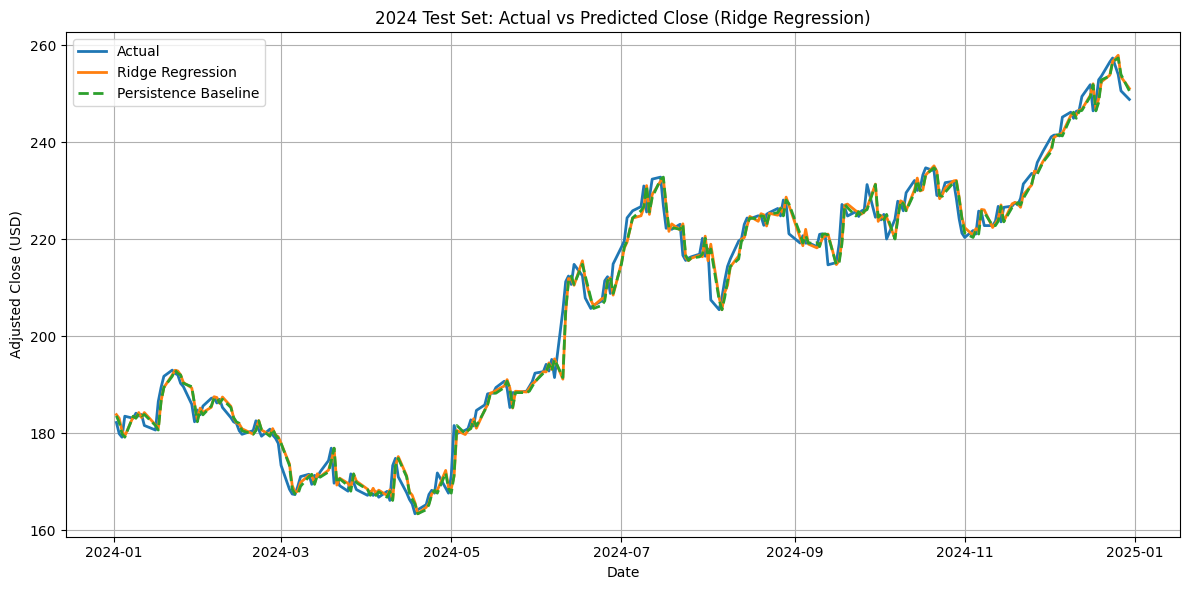

In [3]:
plt.figure(figsize=(12, 6))

plt.plot(
    test_predictions["Date"],
    test_predictions["Actual_Target_Close"],
    label="Actual",
    linewidth=2
)

plt.plot(
    test_predictions["Date"],
    test_predictions["Ridge Regression"],
    label="Ridge Regression",
    linewidth=2
)

plt.plot(
    test_predictions["Date"],
    test_predictions["Persistence_Baseline"],
    label="Persistence Baseline",
    linestyle="--",
    linewidth=2
)

plt.title("2024 Test Set: Actual vs Predicted Close (Ridge Regression)")
plt.xlabel("Date")
plt.ylabel("Adjusted Close (USD)")
plt.legend()
plt.tight_layout()

plt.savefig("actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()


### Explanation: Actual vs Predicted Graph

The Actual vs Predicted graph shows that the Ridge Regression model was able to follow the overall price trend of AAPL in the 2024 test set. The predicted line was generally close to the actual adjusted closing price, which means the model captured the main price movement. However, some prediction errors still occurred, especially during stronger price changes, because stock prices can be affected by sudden market movements and external factors.


## 5. Residual Plot

Residual is calculated as:

\[
\text{Residual} = \text{Actual Value} - \text{Predicted Value}
\]

This plot helps identify the size and pattern of prediction errors over time.


,Date,Actual_Target_Close,Ridge Regression,Residual
0,2024-01-02,182.187744,183.814878,-1.627134
1,2024-01-03,179.873962,183.058693,-3.184731
2,2024-01-04,179.152084,180.433810,-1.281726
3,2024-01-05,183.483063,179.390411,4.092652
4,2024-01-08,183.067780,183.371389,-0.303609


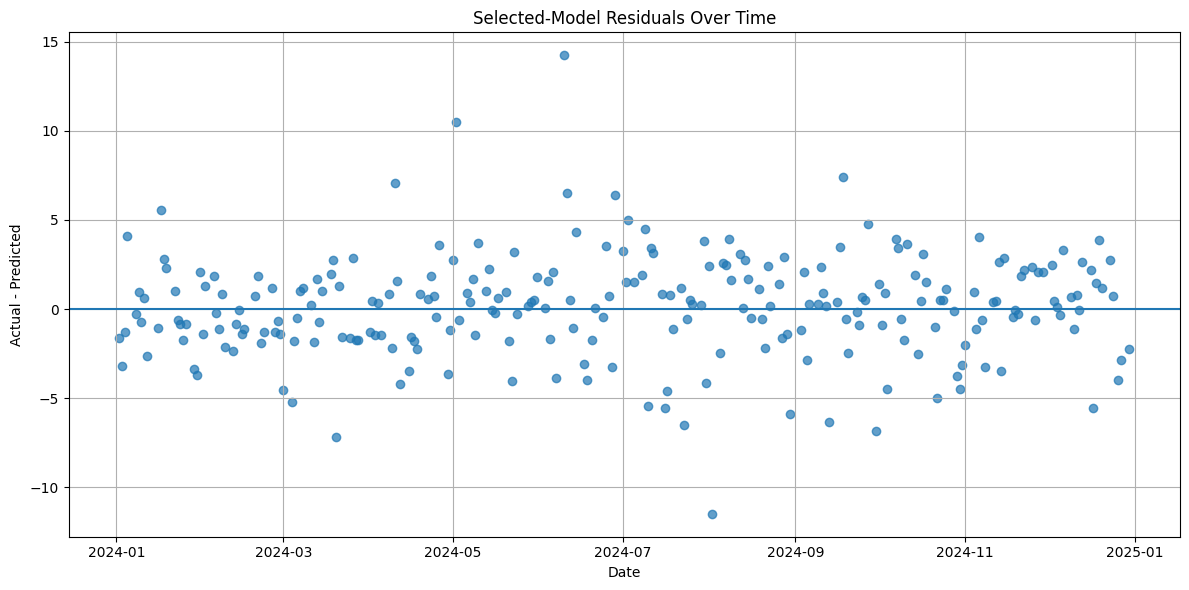

In [4]:
test_predictions["Residual"] = (
    test_predictions["Actual_Target_Close"]
    - test_predictions["Ridge Regression"]
)

display(test_predictions[["Date", "Actual_Target_Close", "Ridge Regression", "Residual"]].head())

plt.figure(figsize=(12, 6))

plt.scatter(
    test_predictions["Date"],
    test_predictions["Residual"],
    alpha=0.7
)

plt.axhline(y=0, linestyle="-")

plt.title("Selected-Model Residuals Over Time")
plt.xlabel("Date")
plt.ylabel("Actual - Predicted")
plt.tight_layout()

plt.savefig("residual_plot.png", dpi=300, bbox_inches="tight")
plt.show()


### Explanation: Residual Plot

The residual plot shows the difference between the actual and predicted AAPL prices. Most residuals were distributed around zero, which indicates that the prediction errors were generally not very large. However, some larger residuals appeared during periods of stronger price movement, showing that the model still had difficulty predicting sudden changes in stock price.


## 6. RMSE Comparison Graph

This graph compares the test RMSE of all evaluated models. A lower RMSE means a smaller prediction error.


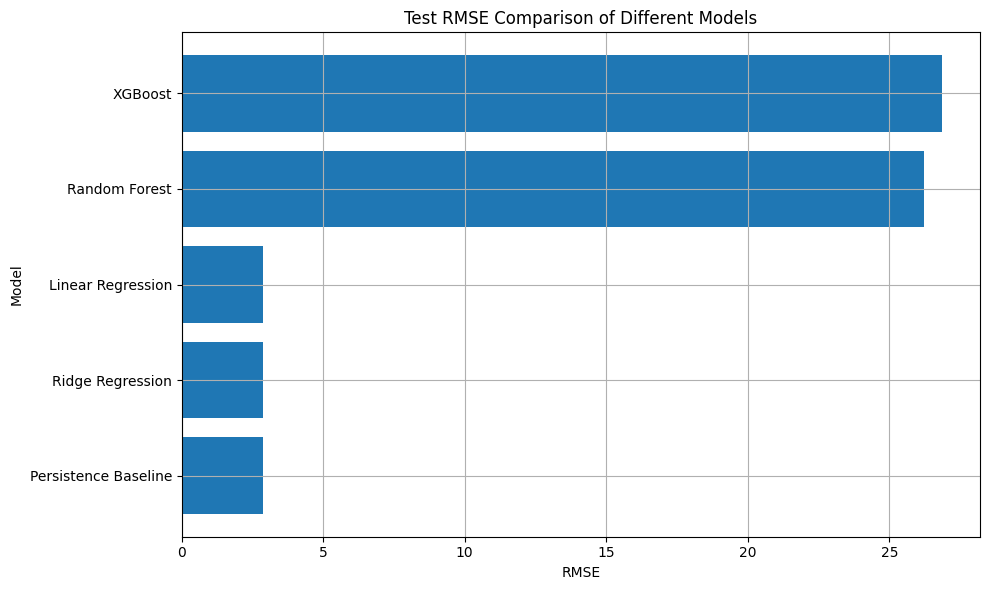

,Model,RMSE,Locked_Selection
0,Persistence Baseline,2.860591,False
1,Ridge Regression,2.876368,True
2,Linear Regression,2.879679,False
3,Random Forest,26.222418,False
4,XGBoost,26.863019,False


In [5]:
rmse_df = test_comparison.sort_values("RMSE", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(rmse_df["Model"], rmse_df["RMSE"])

plt.title("Test RMSE Comparison of Different Models")
plt.xlabel("RMSE")
plt.ylabel("Model")
plt.tight_layout()

plt.savefig("rmse_comparison_graph.png", dpi=300, bbox_inches="tight")
plt.show()

display(rmse_df[["Model", "RMSE", "Locked_Selection"]])


### Explanation: RMSE Comparison Graph

The RMSE comparison chart shows the prediction error of each model on the test set. A lower RMSE value means better prediction performance. The Persistence Baseline remained a very strong benchmark, which shows that next-day stock price prediction is challenging because stock prices are highly continuous over time. However, among the trained machine learning models, Ridge Regression achieved the lowest RMSE and was selected as the best-performing machine learning model.


## 7. Feature Importance Graph

This graph uses permutation feature importance. It measures how much the model performance decreases when a feature is randomly shuffled.

A larger **increase in RMSE after permutation** means the feature is more important to the model.


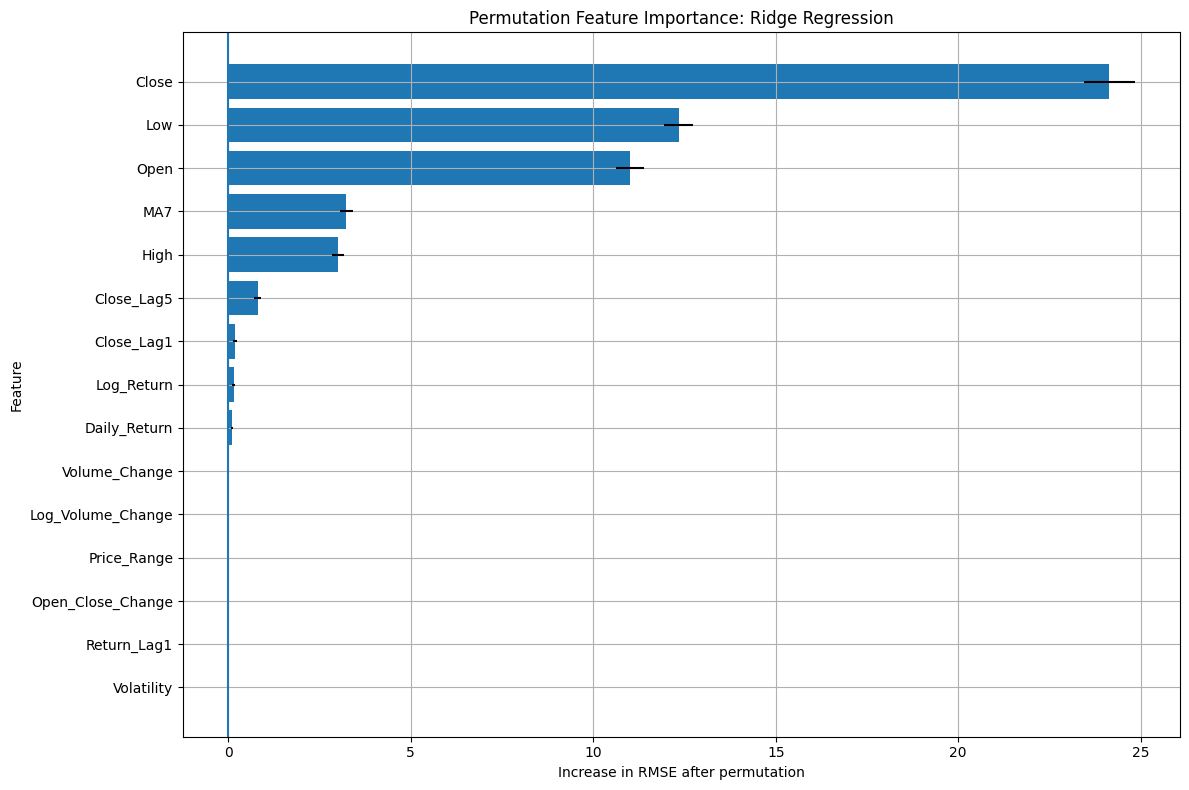

,Feature,Importance_Mean,Importance_Std
0,Close,24.134669,0.699399
1,Low,12.341770,0.392983
2,Open,11.007399,0.385501
3,MA7,3.235217,0.174946
4,High,3.008278,0.173505
5,Close_Lag5,0.802635,0.103116
6,Close_Lag1,0.183606,0.055335
7,Log_Return,0.152022,0.042707
8,Daily_Return,0.100688,0.040342
9,Volume_Change,0.008363,0.007702


In [6]:
top_features = feature_importance.sort_values(
    "Importance_Mean",
    ascending=False
).head(15)

top_features = top_features.sort_values("Importance_Mean", ascending=True)

plt.figure(figsize=(12, 8))

plt.barh(
    top_features["Feature"],
    top_features["Importance_Mean"],
    xerr=top_features["Importance_Std"]
)

plt.title("Permutation Feature Importance: Ridge Regression")
plt.xlabel("Increase in RMSE after permutation")
plt.ylabel("Feature")
plt.axvline(x=0)
plt.tight_layout()

plt.savefig("feature_importance_graph.png", dpi=300, bbox_inches="tight")
plt.show()

display(feature_importance.sort_values("Importance_Mean", ascending=False).head(10))


### Explanation: Feature Importance Graph

The permutation feature importance graph shows how much the model performance decreased when each feature was randomly shuffled. A larger increase in RMSE means the feature was more important to the model. The result shows that Close, Low, and Open were the most important features, followed by MA7 and High. This means the Ridge Regression model mainly relied on recent price information and short-term trend indicators to predict the next-trading-day adjusted closing price.


## 8. Member 2 Summary

Overall, the visualization results show that Ridge Regression was able to follow the general price trend of AAPL in the 2024 test set. The residual plot shows that most prediction errors were close to zero, although larger errors occurred during periods of stronger price movement. The RMSE comparison chart shows that the Persistence Baseline remained a strong benchmark, but Ridge Regression was the best-performing trained machine learning model. The permutation feature importance result shows that the model mainly depended on recent price-related features, especially Close, Low, Open, MA7, High, and Close_Lag5.


## 9. Files Generated by This Notebook

After running all cells, the following image files will be saved in the same folder as this notebook:

- `actual_vs_predicted.png`
- `residual_plot.png`
- `rmse_comparison_graph.png`
- `feature_importance_graph.png`

These images can be sent to the group leader together with this notebook.
